c:\Users\Nourhan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.4.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Train shape : (689284, 37)
Val shape   : (139123, 37)
Test shape  : (139123, 37)
Classes     : ['Bot', 'DDoS', 'DoS-GoldenEye', 'DoS-Hulk', 'DoS-SlowHTTPTest', 'DoS-Slowloris', 'FTP-BruteForce', 'PortScan', 'SSH-BruteForce', 'Web-Attack']


c:\Users\Nourhan\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.91496 | val_accuracy: 0.89364 | val_logloss: 0.25353 |  0:01:31s
epoch 10 | loss: 0.04621 | val_accuracy: 0.98276 | val_logloss: 0.06031 |  0:17:03s
epoch 20 | loss: 0.0449  | val_accuracy: 0.97653 | val_logloss: 0.07752 |  0:34:16s
epoch 30 | loss: 0.04097 | val_accuracy: 0.98333 | val_logloss: 0.05343 |  0:51:24s

Early stopping occurred at epoch 35 with best_epoch = 15 and best_val_logloss = 0.04998


c:\Users\Nourhan\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Best epoch: 15

── Validation Report ──
                  precision    recall  f1-score   support

             Bot     0.9998    0.9996    0.9997     21888
            DDoS     0.9811    0.9759    0.9785     44990
   DoS-GoldenEye     0.8764    0.8885    0.8824      7746
        DoS-Hulk     0.9954    0.9916    0.9935     31889
DoS-SlowHTTPTest     0.9585    0.9924    0.9752       792
   DoS-Slowloris     0.9952    0.9900    0.9926      2293
  FTP-BruteForce     0.9518    0.9889    0.9700       898
        PortScan     0.9993    0.9981    0.9987     13604
  SSH-BruteForce     0.9999    0.9975    0.9987     14579
      Web-Attack     0.6268    0.9910    0.7679       444

        accuracy                         0.9832    139123
       macro avg     0.9384    0.9813    0.9557    139123
    weighted avg     0.9840    0.9832    0.9835    139123


── Test Report (raw) ──
                  precision    recall  f1-score   support

             Bot     0.9997    0.9997    0.9997     21888
  

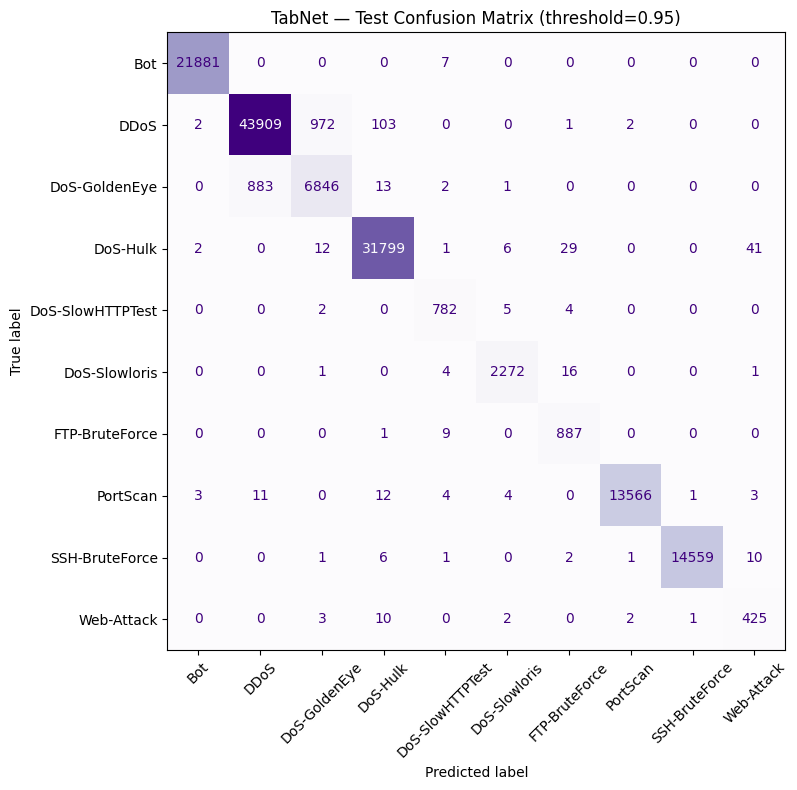


── Per-class ROC-AUC ──
                  ROC-AUC
SSH-BruteForce     1.0000
DoS-Slowloris      1.0000
PortScan           1.0000
FTP-BruteForce     1.0000
DoS-SlowHTTPTest   0.9999
Bot                0.9998
Web-Attack         0.9998
DoS-Hulk           0.9998
DDoS               0.9991
DoS-GoldenEye      0.9966


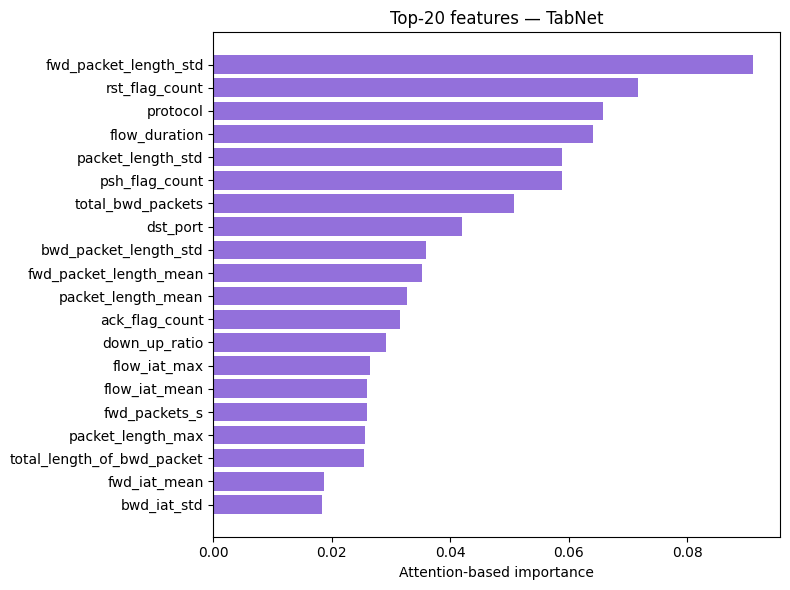

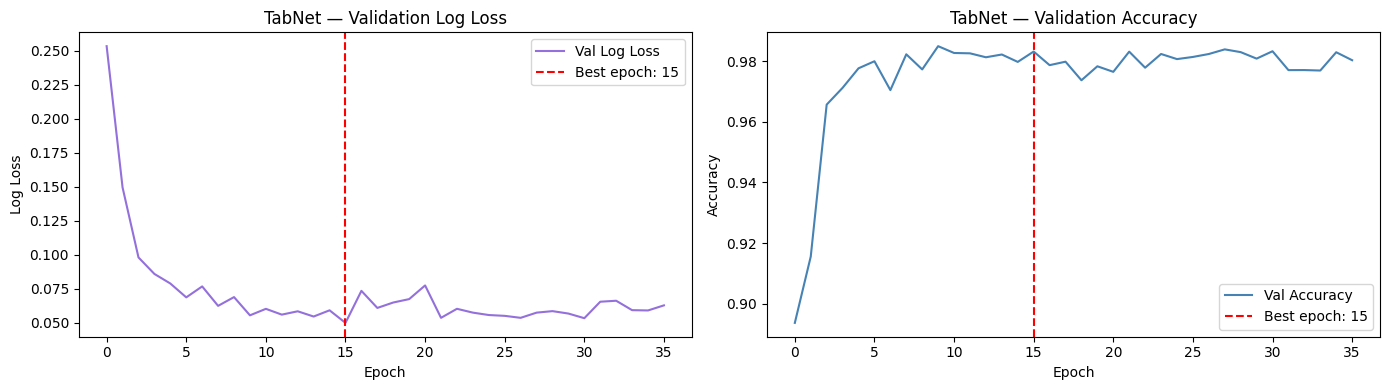

: 

In [ ]:
"""
TabNet Training Pipeline — Network Intrusion Detection
======================================================
Matches your XGBoost setup exactly:
  - Same preprocessed data (processed_outputs/)
  - Same 10-class classification
  - Class-weighted training
  - Web-Attack threshold tuning
  - Probability scores saved for ensembling with XGBoost
"""

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)
from sklearn.preprocessing import label_binarize

# ─────────────────────────────────────────────
# 1. LOAD PREPROCESSED DATA
# ─────────────────────────────────────────────
output_dir = Path("processed_outputs")
models_dir = Path("Models")
models_dir.mkdir(exist_ok=True)

X_train       = joblib.load(output_dir / "X_train_supervised.pkl")
y_train       = joblib.load(output_dir / "y_train_supervised.pkl")
X_val         = joblib.load(output_dir / "X_val_supervised.pkl")
y_val         = joblib.load(output_dir / "y_val_supervised.pkl")
X_test        = joblib.load(output_dir / "X_test_supervised.pkl")
y_test        = joblib.load(output_dir / "y_test_supervised.pkl")
le            = joblib.load(output_dir / "label_encoder_supervised.pkl")
cw            = joblib.load(output_dir / "class_weights_supervised.pkl")
feature_names = joblib.load(output_dir / "feature_names.pkl")

print("Train shape :", X_train.shape)
print("Val shape   :", X_val.shape)
print("Test shape  :", X_test.shape)
print("Classes     :", list(le.classes_))

# ─────────────────────────────────────────────
# 2. PREPARE INPUTS
# TabNet expects numpy float32 arrays
# ─────────────────────────────────────────────
X_train_np = np.array(X_train, dtype=np.float32)
X_val_np   = np.array(X_val,   dtype=np.float32)
X_test_np  = np.array(X_test,  dtype=np.float32)

y_train_np = np.array(y_train, dtype=np.int64)
y_val_np   = np.array(y_val,   dtype=np.int64)
y_test_np  = np.array(y_test,  dtype=np.int64)

# Build sample weights (same logic as your XGBoost)
sample_weights = np.array([cw[label] for label in y_train_np], dtype=np.float32)

# ─────────────────────────────────────────────
# 3. BUILD TABNET MODEL
# ─────────────────────────────────────────────
# Architecture notes:
#   n_d / n_a : embedding & attention width — 64 is strong for 37 features
#   n_steps   : sequential attention steps — 5–6 works well for 10 classes
#   gamma     : feature reusage coefficient (1.3 = moderate reuse)
#   mask_type : 'entmax' gives sparser, sharper attention than 'softmax'
#   momentum  : batch norm momentum — lower = more stable on large datasets

clf = TabNetClassifier(
    n_d            = 64,
    n_a            = 64,
    n_steps        = 6,
    gamma          = 1.3,
    n_independent  = 2,
    n_shared       = 2,
    momentum       = 0.02,
    mask_type      = "entmax",
    optimizer_fn   = __import__("torch").optim.Adam,
    optimizer_params = {"lr": 2e-3, "weight_decay": 1e-5},
    scheduler_fn   = __import__("torch").optim.lr_scheduler.CosineAnnealingLR,
    scheduler_params = {"T_max": 200, "eta_min": 1e-5},
    device_name    = "auto",   # uses GPU if available, else CPU
    seed           = 42,
    verbose        = 10,
)

# ─────────────────────────────────────────────
# 4. TRAIN
# ─────────────────────────────────────────────
clf.fit(
    X_train     = X_train_np,
    y_train     = y_train_np,
    eval_set    = [(X_val_np, y_val_np)],
    eval_name   = ["val"],
    eval_metric = ["accuracy", "logloss"],
    max_epochs  = 200,
    patience    = 20,              # early stopping
    batch_size  = 4096,
    virtual_batch_size = 512,      # ghost batch norm — keep ≤ batch_size
    weights     = sample_weights,  # per-sample weights for class imbalance
    drop_last   = False,
)

print("\nBest epoch:", clf.best_epoch)

# ─────────────────────────────────────────────
# 5. VALIDATION EVALUATION
# ─────────────────────────────────────────────
y_val_pred  = clf.predict(X_val_np)
val_proba   = clf.predict_proba(X_val_np)

print("\n── Validation Report ──")
print(classification_report(
    y_val_np, y_val_pred,
    target_names = le.classes_,
    digits       = 4,
))

# ─────────────────────────────────────────────
# 6. TEST EVALUATION (raw, no threshold)
# ─────────────────────────────────────────────
y_test_pred = clf.predict(X_test_np)
y_test_proba = clf.predict_proba(X_test_np)

print("\n── Test Report (raw) ──")
print(classification_report(
    y_test_np, y_test_pred,
    target_names = le.classes_,
    digits       = 4,
))

# ─────────────────────────────────────────────
# 7. WEB-ATTACK THRESHOLD TUNING
# (same approach as your XGBoost tuning)
# ─────────────────────────────────────────────
web_attack_idx = list(le.classes_).index("Web-Attack")

print("\n── Web-Attack Threshold Sweep ──")
for threshold in [0.80, 0.85, 0.88, 0.90, 0.92, 0.95]:
    y_pred_custom = np.argmax(y_test_proba, axis=1).copy()

    for i, probs in enumerate(y_test_proba):
        sorted_idx = np.argsort(probs)[::-1]
        if sorted_idx[0] == web_attack_idx and probs[web_attack_idx] < threshold:
            y_pred_custom[i] = sorted_idx[1]

    report = classification_report(
        y_test_np, y_pred_custom,
        target_names = le.classes_,
        output_dict  = True,
        zero_division= 0,
    )
    wa  = report["Web-Attack"]
    acc = report["accuracy"]
    print(f"threshold={threshold:.2f} | precision={wa['precision']:.3f} | "
          f"recall={wa['recall']:.3f} | f1={wa['f1-score']:.3f} | "
          f"overall_acc={acc:.4f}")

# Apply best threshold (tune based on sweep output above)
THRESHOLD = 0.95
y_pred_final = np.argmax(y_test_proba, axis=1).copy()
for i, probs in enumerate(y_test_proba):
    sorted_idx = np.argsort(probs)[::-1]
    if sorted_idx[0] == web_attack_idx and probs[web_attack_idx] < THRESHOLD:
        y_pred_final[i] = sorted_idx[1]

print(f"\n── Test Report (threshold={THRESHOLD} for Web-Attack) ──")
print(classification_report(
    y_test_np, y_pred_final,
    target_names = le.classes_,
    digits       = 4,
))

# ─────────────────────────────────────────────
# 8. CONFUSION MATRIX
# ─────────────────────────────────────────────
cm = confusion_matrix(y_test_np, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False, cmap="Purples")
ax.set_title(f"TabNet — Test Confusion Matrix (threshold={THRESHOLD})")
plt.tight_layout()
plt.savefig(output_dir / "confusion_matrix_tabnet.png", dpi=150)
plt.show()

# ─────────────────────────────────────────────
# 9. ROC-AUC PER CLASS
# ─────────────────────────────────────────────
y_test_bin = label_binarize(y_test_np, classes=np.arange(len(le.classes_)))

auc_scores = {}
for i, cls in enumerate(le.classes_):
    auc = roc_auc_score(y_test_bin[:, i], y_test_proba[:, i])
    auc_scores[cls] = round(auc, 4)

auc_df = pd.DataFrame.from_dict(auc_scores, orient="index", columns=["ROC-AUC"])
print("\n── Per-class ROC-AUC ──")
print(auc_df.sort_values("ROC-AUC", ascending=False))

# ─────────────────────────────────────────────
# 10. FEATURE IMPORTANCE (TabNet attention masks)
# ─────────────────────────────────────────────
importances = clf.feature_importances_
fi_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(fi_df["feature"][::-1], fi_df["importance"][::-1], color="mediumpurple")
ax.set_xlabel("Attention-based importance")
ax.set_title("Top-20 features — TabNet")
plt.tight_layout()
plt.savefig(output_dir / "feature_importance_tabnet.png", dpi=150)
plt.show()

# ─────────────────────────────────────────────
# 11. TRAINING CURVE
# ─────────────────────────────────────────────
history = clf.history

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history["val_logloss"], label="Val Log Loss", color="mediumpurple")
axes[0].axvline(clf.best_epoch, color="red", linestyle="--",
                label=f"Best epoch: {clf.best_epoch}")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Log Loss")
axes[0].set_title("TabNet — Validation Log Loss")
axes[0].legend()

axes[1].plot(history["val_accuracy"], label="Val Accuracy", color="steelblue")
axes[1].axvline(clf.best_epoch, color="red", linestyle="--",
                label=f"Best epoch: {clf.best_epoch}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("TabNet — Validation Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig(output_dir / "training_curve_tabnet.png", dpi=150)
plt.show()

# # ─────────────────────────────────────────────
# # 12. SAVE ARTIFACTS
# # ─────────────────────────────────────────────
# clf.save_model(str(models_dir / "tabnet_model"))          # saves .zip

# joblib.dump(y_val_pred,    models_dir / "tabnet_preds_val.pkl")
# joblib.dump(y_pred_final,  models_dir / "tabnet_preds_test.pkl")
# joblib.dump(val_proba,     models_dir / "tabnet_val_scores.pkl")
# joblib.dump(y_test_proba,  models_dir / "tabnet_test_scores.pkl")
# joblib.dump(THRESHOLD,     models_dir / "tabnet_web_attack_threshold.pkl")

# print("\nTabNet artifacts saved to:", models_dir.resolve())

# # ─────────────────────────────────────────────
# # 13. ENSEMBLE WITH XGBOOST
# # Weighted average of probabilities from both models
# # ─────────────────────────────────────────────
# print("\n── XGBoost + TabNet Ensemble ──")

# xgb_proba = joblib.load(models_dir / "xgb_test_scores.pkl")

# for xgb_w, tab_w in [(0.7, 0.3), (0.6, 0.4), (0.5, 0.5)]:
#     ensemble_proba = xgb_w * xgb_proba + tab_w * y_test_proba

#     # Apply Web-Attack threshold on ensemble probabilities
#     y_ens_pred = np.argmax(ensemble_proba, axis=1).copy()
#     for i, probs in enumerate(ensemble_proba):
#         sorted_idx = np.argsort(probs)[::-1]
#         if sorted_idx[0] == web_attack_idx and probs[web_attack_idx] < THRESHOLD:
#             y_ens_pred[i] = sorted_idx[1]

#     report = classification_report(
#         y_test_np, y_ens_pred,
#         target_names = le.classes_,
#         output_dict  = True,
#         zero_division= 0,
#     )
#     wa  = report["Web-Attack"]
#     acc = report["accuracy"]
#     print(f"XGB×{xgb_w} + TabNet×{tab_w} | "
#           f"Web-Attack f1={wa['f1-score']:.4f} | overall_acc={acc:.4f}")

# # Save best ensemble proba (adjust weights after reviewing output above)
# BEST_XGB_W, BEST_TAB_W = 0.6, 0.4
# best_ensemble_proba = BEST_XGB_W * xgb_proba + BEST_TAB_W * y_test_proba
# joblib.dump(best_ensemble_proba, models_dir / "ensemble_xgb_tabnet_test_scores.pkl")

# print(f"\nBest ensemble proba (XGB×{BEST_XGB_W} + TabNet×{BEST_TAB_W}) saved.")
# print("Done ✓")